# Tutorial: Forecasting ENSO using Machine Learning

# Introduction

The **El Niño–Southern Oscillation (ENSO)** is a major driver of climate variability, influencing regional and global weather patterns [1-2]. It has been linked to extreme weather events across the globe, including droughts, floods, and shifts in precipitation [3-5]. Weather centres around the world actively forecast ENSO to anticipate these patterns [6].

In this tutorial, we will demonstrate how to build machine learning models to forecast ENSO using the **Niño3.4 index** as a proxy for ENSO state. The tutorial is divided into three main parts:

- **Data loading and pre-processing**: Compute the monthly Niño3.4 index using air temperature data from the ERA5 reanalysis.
> **Note:** The Niño3.4 index is typically calculated using sea surface temperature (SST). However, since ERA5 does not provide actual SST, we will approximate it using surface air temperature, i.e., the 2-metre air temperature (`t2m`).

- **One-month ahead forecasting**: Train and evaluate an XGBoost model to predict the Niño3.4 index one month into the future.

- **Three-month ahead forecasting**: Build and test a multi-layer perceptron (MLP) to predict Niño3.4 with a three-month lead time.

By the end of this tutorial, you will understand the full pipeline for building ML-based ENSO prediction systems from data loading to evaluation.


---

# Part 1: Data loading and pre-processing

### 1. Load and process ERA5 2-metre air temperature (t2m) data. We want to calculate the Niño3.4 index from the t2m anomalies in the region 5°N–5°S, 170°W–120°W. 


/g/data/kd24/tjl/src/PyEarthTools/packages/data/src/pyearthtools/data/indexes/indexes.py:809: IndexWarning: Data requested at a higher resolution than available. hour > month
  warnings.warn(


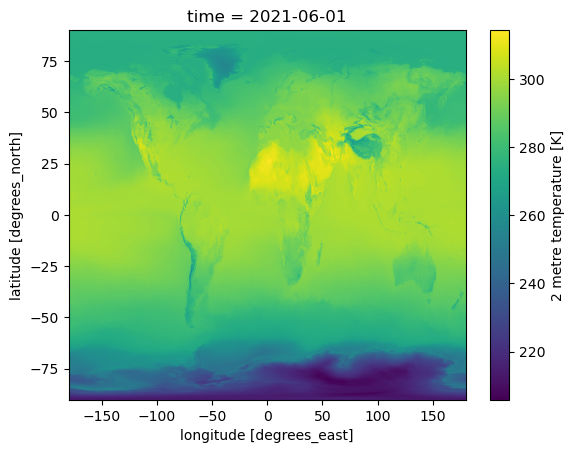

In [1]:
# Necessary import
import pyearthtools.data
import pyearthtools.pipeline as petpipe
import site_archive_nci
import warnings
import xarray as xr
import plotly.express as px

# Total time frame for training the model
start = '1970-01-01'
end = '2024-12-31'

# Start by considering a specific date for visualising the process on one sample
doi = '2021-06-09T06' # Note - if you change 'product' to 'reanalysis' you can get the 6-hour timesteps
variables_of_interest = ['2t']
product = 'monthly-averaged'
accessor = pyearthtools.data.archive.ERA5(variables_of_interest, product=product)
accessor[doi]['2t'].plot()

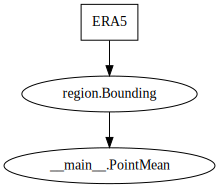

In [2]:
min_lat = -5
max_lat = 5
min_lon = -170
max_lon = -120


class PointMean(pyearthtools.data.transforms.Transform):

    def apply(self, dataset, **kwargs):
        dataset['2t'] = dataset['2t'].mean(dim=['latitude', 'longitude'])
        return dataset

    

pipeline = petpipe.Pipeline(
    accessor,
    pyearthtools.data.transform.region.Bounding(min_lat, max_lat, min_lon, max_lon),
    PointMean(),
    sampler=pyearthtools.pipeline.samplers.Default(),
    iterator=pyearthtools.pipeline.iterators.DateRange(start, end, interval='1 month')    
)
pipeline




In [3]:
%%time
# Takes around ten seconds
all_steps = None
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    all_steps = list(pipeline)

CPU times: user 6.76 s, sys: 1.26 s, total: 8.02 s
Wall time: 10.2 s


In [4]:
all_temps = [s['2t'] for s in all_steps]
ds = xr.concat(all_temps, dim='time')

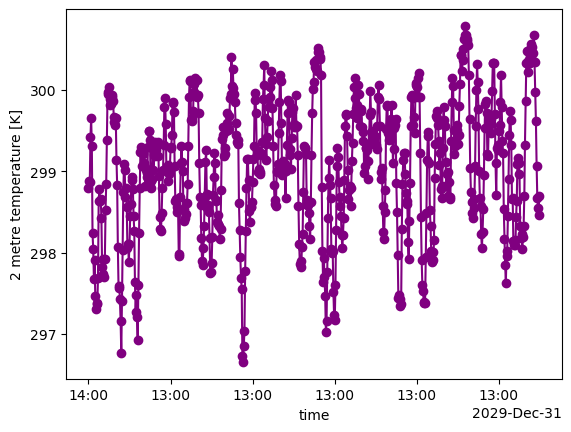

In [5]:
ds.plot.line(color="purple", marker="o");

### 2. Average t2 over the spatial domain of the Niño3.4 index

In [6]:
# Convert to pandas DataFrame with 3 columns 'year' 'month' and 't2m' (i.e. 2t timeseries)
df = ds.to_dataframe(name='t2m').reset_index()

# Extract year and month from 'time'
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month

# Keep required columns
t2_df = df[['year', 'month', 't2m']]

print("\nPrinting first 10 rows of t2_df:")
print(t2_df.head(10))


Printing first 10 rows of t2_df:
   year  month         t2m
0  1970      1  298.799964
1  1970      2  298.884142
2  1970      3  298.863824
3  1970      4  299.425736
4  1970      5  299.650770
5  1970      6  299.316589
6  1970      7  298.237027
7  1970      8  298.046338
8  1970      9  297.680157
9  1970     10  297.906577


### 3. Calculate the Niño3.4 index

In [7]:
# Calculate monthly climatology
monthly_clim = t2_df.groupby('month')['t2m'].mean()
print("Printing monthly climatology (mean t2m by month):")
print(monthly_clim)

# Calculate monthly anomalies
#ds_reanalysis_monthly_anom = ds_reanalysis_monthly.groupby('time.month') - ds_reanalysis_monthly_clim -- delete
# Map the climatology back to the dataframe to get anomalies
t2_df['monthly_clim'] = t2_df['month'].map(monthly_clim)
t2_df['anom'] = t2_df['t2m'] - t2_df['monthly_clim']
 
# Minus 5-year moving average to remove trend
#ds_reanalysis_nino = ds_reanalysis_nino - ds_reanalysis_nino.rolling(time=60, center=True).mean() -- delete
t2_df['anom_detrended'] = t2_df['anom'] - t2_df['anom'].rolling(window=60, center=True, min_periods=1).mean()

 
# Apply 5 month running average
t2_df['anom_smoothed'] = t2_df['anom_detrended'].rolling(window=5, center=True, min_periods=1).mean()

 
# Normalise by the standard deviation of the time series
#ds_reanalysis_nino = ( ds_reanalysis_nino / ds_reanalysis_nino.std('time') ).compute() -- delete
std_val = t2_df['anom_smoothed'].std()
t2_df['nino3.4'] = t2_df['anom_smoothed'] / std_val

print("\nPrinting first 10 rows of t2_df:")
print(t2_df.head(10))

Printing monthly climatology (mean t2m by month):
month
1     298.664784
2     298.846780
3     299.178853
4     299.585783
5     299.701533
6     299.568230
7     299.242830
8     298.925642
9     298.792747
10    298.731676
11    298.721546
12    298.673998
Name: t2m, dtype: float64

Printing first 10 rows of t2_df:
   year  month         t2m  monthly_clim      anom  anom_detrended  \
0  1970      1  298.799964    298.664784  0.135180        0.797918   
1  1970      2  298.884142    298.846780  0.037362        0.653045   
2  1970      3  298.863824    299.178853 -0.315029        0.253487   
3  1970      4  299.425736    299.585783 -0.160047        0.357922   
4  1970      5  299.650770    299.701533 -0.050762        0.419813   
5  1970      6  299.316589    299.568230 -0.251641        0.170821   
6  1970      7  298.237027    299.242830 -1.005803       -0.629650   
7  1970      8  298.046338    298.925642 -0.879304       -0.545729   
8  1970      9  297.680157    298.792747 -1.112591

Prepare datasets with lagged features for forecasting.

---

# Part 2: One-month forecast using XGBoost

---

# Part 3: Three-month Forecast using MLP

---

# Exercices
**You want to practice more? Try these:**
- Modify the forecast lead time (e.g., two months or six months ahead).
- Recalculate and use alternative ENSO indices (e.g., Niño3, Niño4)
- Experiment with different architectures or hyperparameters for the MLP (e.g., number of layers, neurons, learning rate).

---

# References
1. Karoly, D. J. Southern hemisphere circulation features associated with El Niño–Southern Oscillation events. *J. Clim.* **2**, 1239–1252 (1989).
2. Alexander, M. A. et al. The atmospheric bridge: The influence of ENSO teleconnections on air–sea interaction over the global oceans. *J. Clim.* **15**, 2205–2231 (2002).
3. Lyon, B. & Barnston, A. G. ENSO and the spatial extent of interannual precipitation extremes in tropical land areas. *J. Clim.* **18**, 5095–5109 (2005).  
4. Vicente‐Serrano, S. M. et al. A multiscalar global evaluation of the impact of ENSO on droughts. *J. Geophys. Res. Atmos.* **116**, (2011).  
5. Chiew, F. H. S. & McMahon, T. A. Global ENSO-streamflow teleconnection, streamflow forecasting and interannual variability. *Hydrol. Sci. J.* **47**, 505–522 (2002).
6. Kirtman, B. P. et al. Current status of ENSO forecast skill: A report to the CLIVAR Working Group on Seasonal to Interannual Prediction. (2001)